# Batch effect in clonal embeddings

Proper removal of the batch effect in the gene expression embedding is essential for the clonal embeddings construction. In the case of undercorrection, we can see clusters of clones from the same batch. To illustrate it, we can take a clonal embedding from Liu et al. NSCLC cohort, which was already analyzed in the previous notebook.

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import clone2vec as c2v
import scanpy.external as sce

sc.set_figure_params(dpi=80)
sc.settings.verbosity = 3
sns.set_style("ticks")

We're going to use the output clonal embedding from the notebook ***Graph input for clonal embeddings construction***.

In [2]:
clones = sc.read_h5ad("Liu_CD8_bbknn_c2v.h5ad")

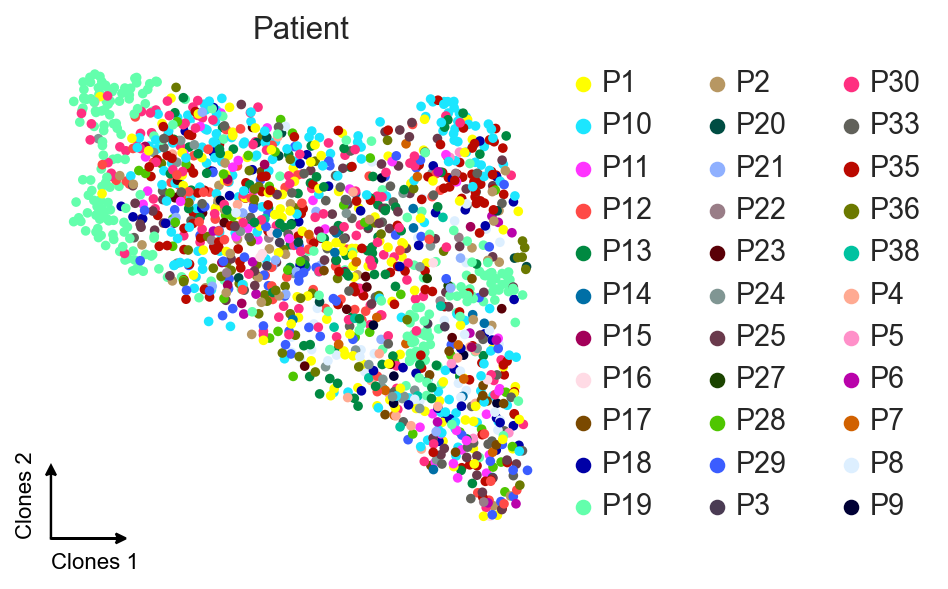

In [4]:
ax = sc.pl.umap(clones, color="gex_patient", title="Patient",
                frameon=False, show=False)
c2v.pl.embedding_axis(ax, label="Clones")

We see a clear batch effect between patient P19 and other patients. Because all these clones exist in the same clone2vec space, we can use some methods for bath corrections that were built for the gene expression analysis: for example, `Harmony` or `bbknn`. Here we will use `bbknn` to build an integrated clonal embedding.

In [5]:
sce.pp.bbknn(clones, use_rep="clone2vec", batch_key="gex_patient",
             neighbors_within_batch=2, trim=20)

computing batch balanced neighbors
	finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:04)


In [6]:
sc.tl.umap(clones)

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:03)


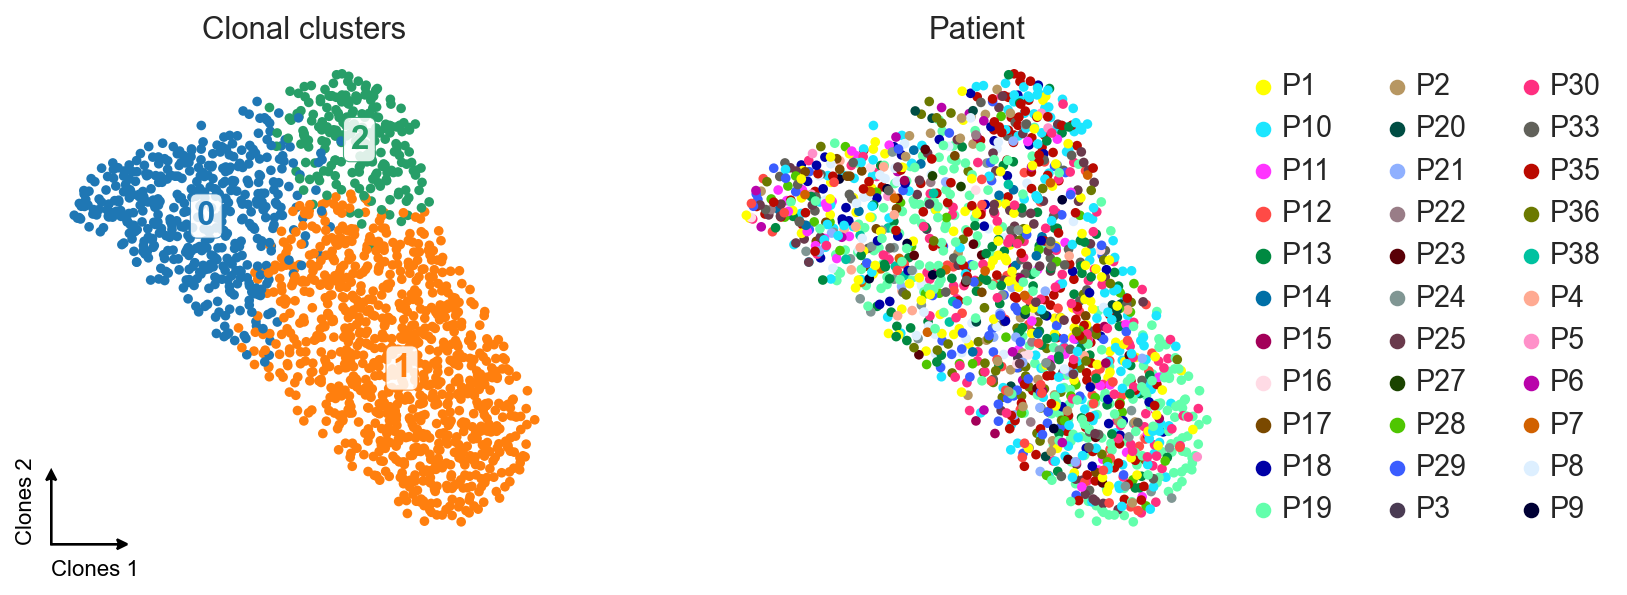

In [7]:
axes = sc.pl.umap(
    clones,
    color=["leiden", "gex_patient"],
    title=["Clonal clusters", "Patient"],
    frameon=False,
    show=False,
)

c2v.pl.embedding_axis(axes[0], label="Clones")
c2v.pl.fancy_legend(axes[0], fontweight="bold", center_loc=True, textsize=15)

Here we see that our original clustering wasn't affected by this batch effect, therefore it was relatively safe to work with the original embedding. We can make sure that marker genes' behavior stayed the same.

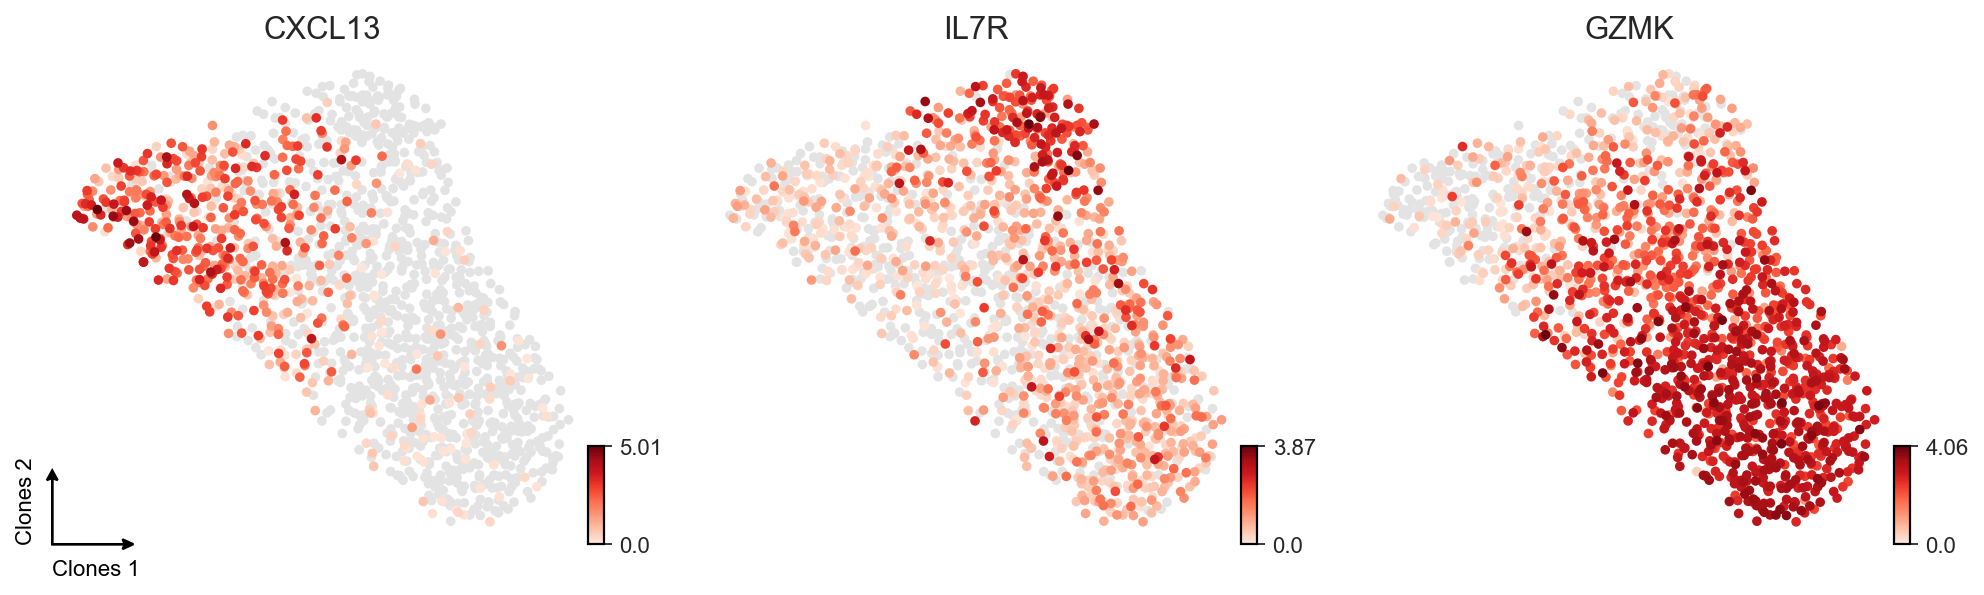

In [8]:
axes = sc.pl.umap(clones, color=["CXCL13", "IL7R", "GZMK"], frameon=False,
                  show=False, cmap=c2v.pl.Reds)

c2v.pl.small_cbar(axes)
c2v.pl.embedding_axis(axes[0], label="Clones")